In [ ]:
# upload libraries
# ==========================================
# 1. المكتبات الأساسية (Manipulation & EDA)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 2. أدوات Preprocessing و Pipelines
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer

# ==========================================
# 3. الخوارزميات (Algorithms)
# ==========================================
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# ==========================================
# 4. مقاييس الأداء (Metrics)
# ==========================================
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 5. أدوات متقدمة (XAI & Advanced Imputation)
# ==========================================
# تفعيل الـ Iterative Imputer (تجريبي في sklearn)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# مكتبة التفسير (SHAP)
try:
    import shap
except ImportError:
    !pip install shap
    import shap

print("✅ الترسانة واجدة! كاع المكتبات تشارجاو بنجاح.")

✅ الترسانة واجدة! كاع المكتبات تشارجاو بنجاح.


In [ ]:
# ==========================================
# 2. تحميل البيانات (Loading Dataset)
# ==========================================

# الرابط المباشر للداتا من GitHub
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"

# تحميل الداتا
df = pd.read_csv(url)

# فحص أولي للداتا
print("✅ تم تحميل البيانات بنجاح!")
print(f"الشكل العام للداتا: {df.shape[0]} سطر و {df.shape[1]} عمود.")

# عرض أول 5 أسطر
df.head()

✅ تم تحميل البيانات بنجاح!
الشكل العام للداتا: 284807 سطر و 31 عمود.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# معلومات على نوعية الأعمدة (كلهم أرقام Float64 ما عدا Class)
print("\n--- معلومات تقنية عن الأعمدة ---")
print(df.info())

# فحص القيم المفقودة (مهم بزاف لفقرة Preprocessing)
print("\n--- فحص القيم المفقودة (Missing Values) ---")
print(df.isnull().sum().sum())


--- معلومات تقنية عن الأعمدة ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807

/tmp/ipython-input-3399467396.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='magma')


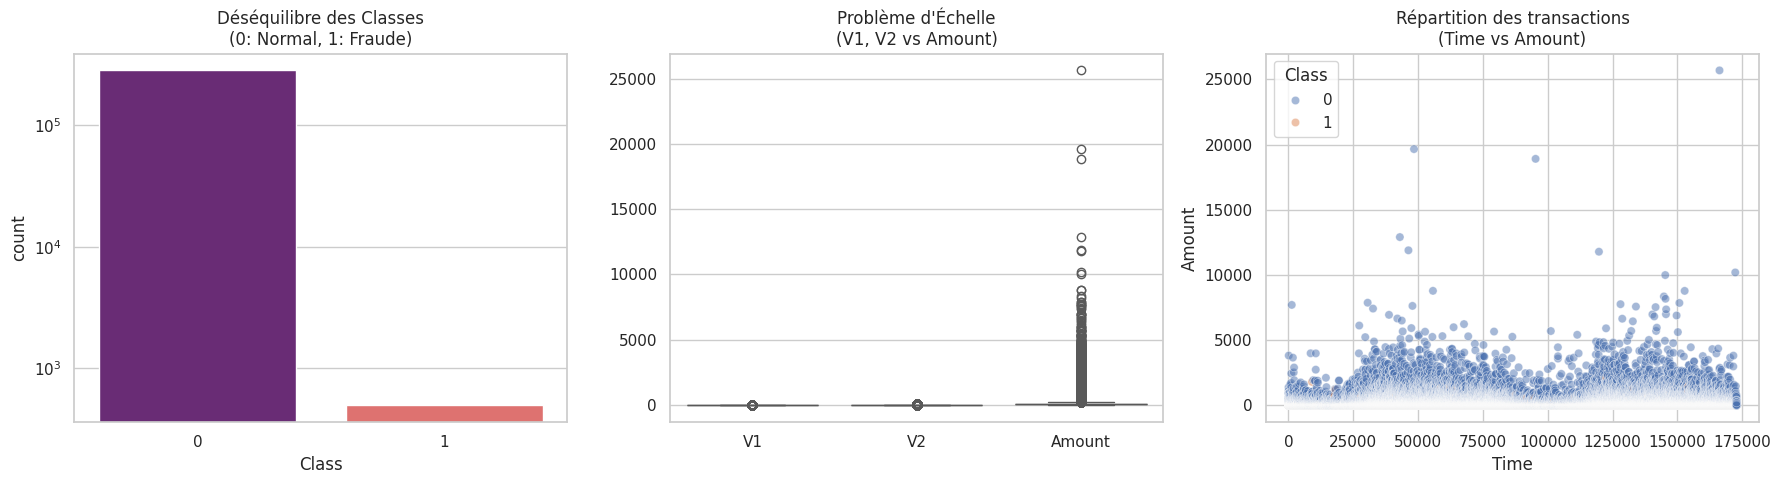

In [ ]:
# ==========================================
# 3. تحليل البيانات بصرياً (Visualization)
# ==========================================

# إعداد شكل المبيانات
sns.set(style="whitegrid")
plt.figure(figsize=(18, 5))

# 1. مبيان عدم التوازن (Class Imbalance)
# هادا كيبين بلي الشفارة قلال بزاف مقارنة بالناس العاديين
plt.subplot(1, 3, 1)
sns.countplot(x='Class', data=df, palette='magma')
plt.title('Déséquilibre des Classes\n(0: Normal, 1: Fraude)')
plt.yscale('log') # استعملنا اللوغاريتم حيت الفرق كبير بزااااف

# 2. مبيان تباين الموازين (Feature Scales)
# هادا كيبين علاش ضروري خاصنا الـ Scaling (العبار)
plt.subplot(1, 3, 2)
# غانقارنو Amount مع بعض ميزات V باش يبان الفرق فـ الأرقام
sns.boxplot(data=df[['V1', 'V2', 'Amount']], palette='Set2')
plt.title('Problème d\'Échelle\n(V1, V2 vs Amount)')

# 3. مبيان العلاقة بين الوقت والمبلغ (Time vs Amount)
plt.subplot(1, 3, 3)
sns.scatterplot(x='Time', y='Amount', hue='Class', data=df, alpha=0.5)
plt.title('Répartition des transactions\n(Time vs Amount)')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# فصل الميزات (X) عن الهدف (y)
X = df.drop('Class', axis=1)
y = df['Class']

# تقسيم 80% للتدريب و 20% للاختبار
# كنستعملو stratify=y باش نحافظو على نفس نسبة الغش في كاع الأجزاء
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# ==========================================
# 4. Pipeline 1: Minimal Preprocessing
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, recall_score

# 1. Define the 3 selected models
models_p1 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 2. Storage for results
p1_results = []

print("--- Training Pipeline 1 (Minimal Preprocessing) ---")

for name, model in models_p1.items():
    # Construct the pipeline as per requirements
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')), # Basic cleaning
        ('classifier', model)                        # No Scaling or Encoding
    ])

    # Train the pipeline
    pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = pipeline.predict(X_test)

    # Evaluate
    p1_results.append({
        'Pipeline': 'P1 (Minimal)',
        'Algorithm': name,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })
    print(f"✅ {name} Completed.")

# 3. Display Results in a DataFrame
df_p1_results = pd.DataFrame(p1_results)
print("\nResults for Pipeline 1:")
print(df_p1_results)

--- Training Pipeline 1 (Minimal Preprocessing) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Logistic Regression Completed.
✅ K-Nearest Neighbors Completed.
✅ Random Forest Completed.

Results for Pipeline 1:
       Pipeline            Algorithm  F1-Score    Recall
0  P1 (Minimal)  Logistic Regression  0.745763  0.673469
1  P1 (Minimal)  K-Nearest Neighbors  0.059406  0.030612
2  P1 (Minimal)        Random Forest  0.874317  0.816327


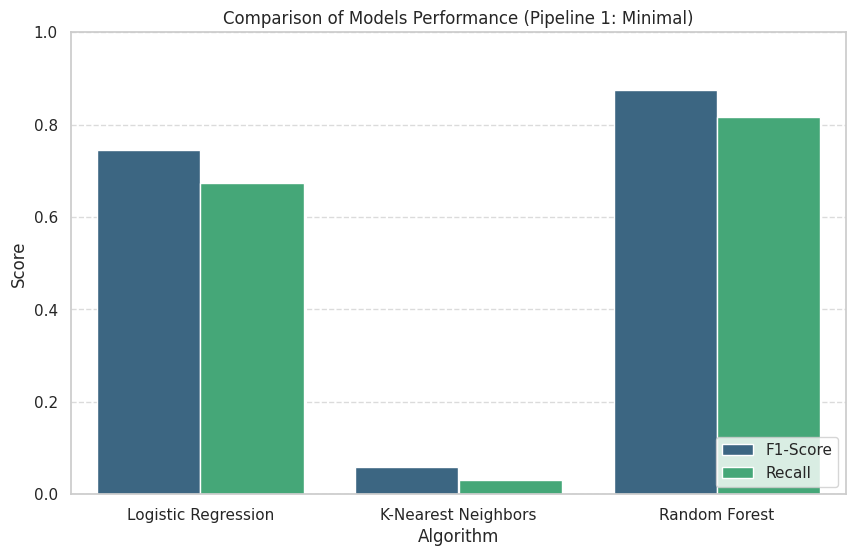

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحويل النتائج لجدول منظم
df_p1 = pd.DataFrame(p1_results)

# رسم مبيان لمقارنة الـ F1-Score والـ Recall
plt.figure(figsize=(10, 6))
melted_df = df_p1.melt(id_vars='Algorithm', value_vars=['F1-Score', 'Recall'],
                       var_name='Metric', value_name='Score')

sns.barplot(data=melted_df, x='Algorithm', y='Score', hue='Metric', palette='viridis')

plt.title('Comparison of Models Performance (Pipeline 1: Minimal)')
plt.ylim(0, 1) # السلم من 0 لـ 1
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# ==========================================
# 5. Pipeline 2: Standard Preprocessing
# ==========================================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 1. تحديد الأعمدة الرقمية (كلها فـ هاد الحالة) والتصنيفية (إيلا كانت)
numeric_features = X.columns.tolist()
categorical_features = [] # خاوي حيت الداتا كلها PCA أرقام

# 2. بناء الـ Preprocessor (Standard)
preprocessor_p2 = ColumnTransformer(
    transformers=[
        # المعالجة الرقمية: تعمار الفراغات + توحيد القياس
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        # المعالجة التصنيفية: تعمار الفراغات + Encoding
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ])

# 3. تعريف الموديلات بـ 3
models_p2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

p2_results = []

print("--- التدريب على Pipeline 2 (Standard)... ---")

for name, model in models_p2.items():
    # دمج المعالجة مع الموديل
    current_p2 = Pipeline([
        ('preprocessor', preprocessor_p2),
        ('classifier', model)
    ])

    # التدريب والتوقع
    current_p2.fit(X_train, y_train)
    y_pred = current_p2.predict(X_test)

    # تسجيل النتائج
    p2_results.append({
        'Pipeline': 'P2 (Standard)',
        'Algorithm': name,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })
    print(f"✅ {name} سالا.")

# عرض النتائج
import pandas as pd
df_p2 = pd.DataFrame(p2_results)
print("\n--- نتائج Pipeline 2 ---")
print(df_p2)

--- التدريب على Pipeline 2 (Standard)... ---
✅ Logistic Regression سالا.
✅ K-Nearest Neighbors سالا.
✅ Random Forest سالا.

--- نتائج Pipeline 2 ---
        Pipeline            Algorithm  F1-Score    Recall
0  P2 (Standard)  Logistic Regression  0.716763  0.632653
1  P2 (Standard)  K-Nearest Neighbors  0.858696  0.806122
2  P2 (Standard)        Random Forest  0.874317  0.816327


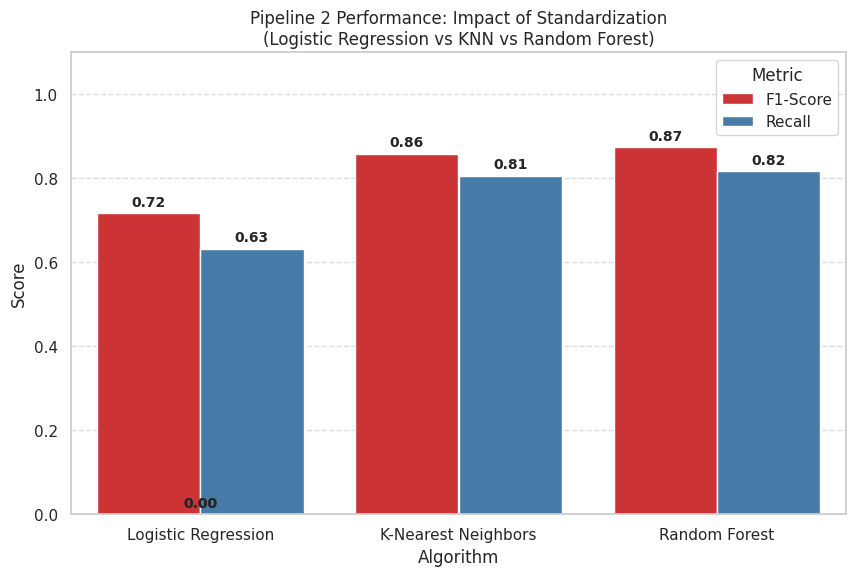

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# تحويل النتائج لجدول منظم
df_p2_viz = pd.DataFrame(p2_results)

# إعداد شكل المبيان
plt.figure(figsize=(10, 6))
melted_p2 = df_p2_viz.melt(id_vars='Algorithm', value_vars=['F1-Score', 'Recall'],
                           var_name='Metric', value_name='Score')

# رسم المبيان بألوان واضحة
sns.barplot(data=melted_p2, x='Algorithm', y='Score', hue='Metric', palette='Set1')

plt.title('Pipeline 2 Performance: Impact of Standardization\n(Logistic Regression vs KNN vs Random Forest)')
plt.ylim(0, 1.1) # مساحة للأرقام فوق الأعمدة
plt.grid(axis='y', linestyle='--', alpha=0.7)

# إضافة الأرقام فوق الأعمدة للدقة
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 8),
                       textcoords='offset points',
                       fontsize=10, weight='bold')

plt.show()

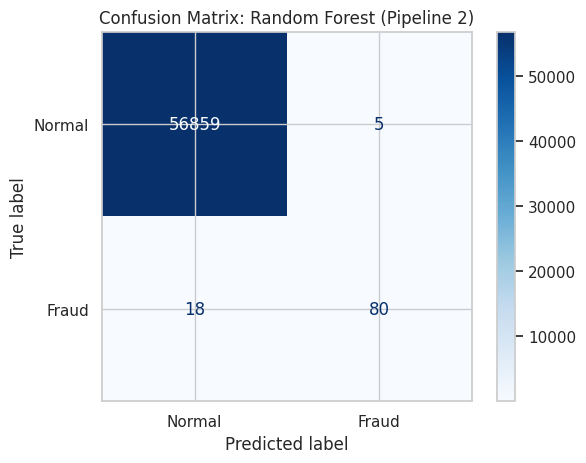

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# بناء الموديل بوحدو للرسم (مثال بـ Random Forest)
best_p2_pipe = Pipeline([
    ('preprocessor', preprocessor_p2),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])
best_p2_pipe.fit(X_train, y_train)
y_pred_cm = best_p2_pipe.predict(X_test)

# رسم المصفوفة
cm = confusion_matrix(y_test, y_pred_cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Random Forest (Pipeline 2)')
plt.show()

In [ ]:

#//pipline 3 : advanced preprocessing
from imblearn.pipeline import Pipeline # ضروري تستعمل هادي ماشي ديال sklearn
from imblearn.over_sampling import SMOTE, SVMSMOTE, KMeansSMOTE
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# 1. تعريف أنواع الـ Resampling اللي غنجربو
resamplers = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTE-Tomek': SMOTETomek(random_state=42),
    'SMOTE-ENN': SMOTEENN(random_state=42),
    'SVM-SMOTE': SVMSMOTE(random_state=42)
}

# 2. الموديلات (حيدنا class_weight حيت غنديرو Resampling يدوي)
models_p3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

p3_advanced_results = []

print("--- التدريب على Pipeline 3 المطور (Resampling + Selection) ---")

for resample_name, resampler in resamplers.items():
    print(f"\n🚀 كنجربو دابا تقنية: {resample_name}")

    for model_name, model in models_p3.items():
        # بناء الـ Pipeline
        # ملاحظة: StandardScaler أحسن لـ KNN و Logistic، و RobustScaler مزيان ليهم كاملين
        p3_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler()),      # Scaling adapté
            ('selector', SelectKBest(f_classif, k=20)), # Selection de variables
            ('pca', PCA(n_components=15)),   # Réduction de dimension
            ('resample', resampler),         # التقنية ديال SMOTE اللي خدامين عليها
            ('classifier', model)
        ])

        # التدريب
        p3_pipe.fit(X_train, y_train)
        y_pred = p3_pipe.predict(X_test)

        # تسجيل النتائج
        p3_advanced_results.append({
            'Resampler': resample_name,
            'Algorithm': model_name,
            'F1-Score': f1_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred)
        })
        print(f"   ✅ {model_name} سالا.")

# تحويل النتائج لجدول ومنظم حسب الـ Recall
df_p3_adv = pd.DataFrame(p3_advanced_results).sort_values(by='Recall', ascending=False)
print("\n--- النتائج النهائية للـ Pipeline 3 المطور ---")
print(df_p3_adv)

--- التدريب على Pipeline 3 المطور (Resampling + Selection) ---

🚀 كنجربو دابا تقنية: SMOTE
   ✅ Logistic Regression سالا.
   ✅ K-Nearest Neighbors سالا.
   ✅ Random Forest سالا.

🚀 كنجربو دابا تقنية: SMOTE-Tomek
   ✅ Logistic Regression سالا.
   ✅ K-Nearest Neighbors سالا.
   ✅ Random Forest سالا.

🚀 كنجربو دابا تقنية: SMOTE-ENN
   ✅ Logistic Regression سالا.
   ✅ K-Nearest Neighbors سالا.
   ✅ Random Forest سالا.

🚀 كنجربو دابا تقنية: SVM-SMOTE
   ✅ Logistic Regression سالا.
   ✅ K-Nearest Neighbors سالا.
   ✅ Random Forest سالا.

--- النتائج النهائية للـ Pipeline 3 المطور ---
      Resampler            Algorithm  F1-Score    Recall
0         SMOTE  Logistic Regression  0.100559  0.918367
3   SMOTE-Tomek  Logistic Regression  0.100559  0.918367
6     SMOTE-ENN  Logistic Regression  0.097297  0.918367
9     SVM-SMOTE  Logistic Regression  0.179255  0.908163
7     SMOTE-ENN  K-Nearest Neighbors  0.409756  0.857143
1         SMOTE  K-Nearest Neighbors  0.459016  0.857143
4   SMOTE-Tomek 

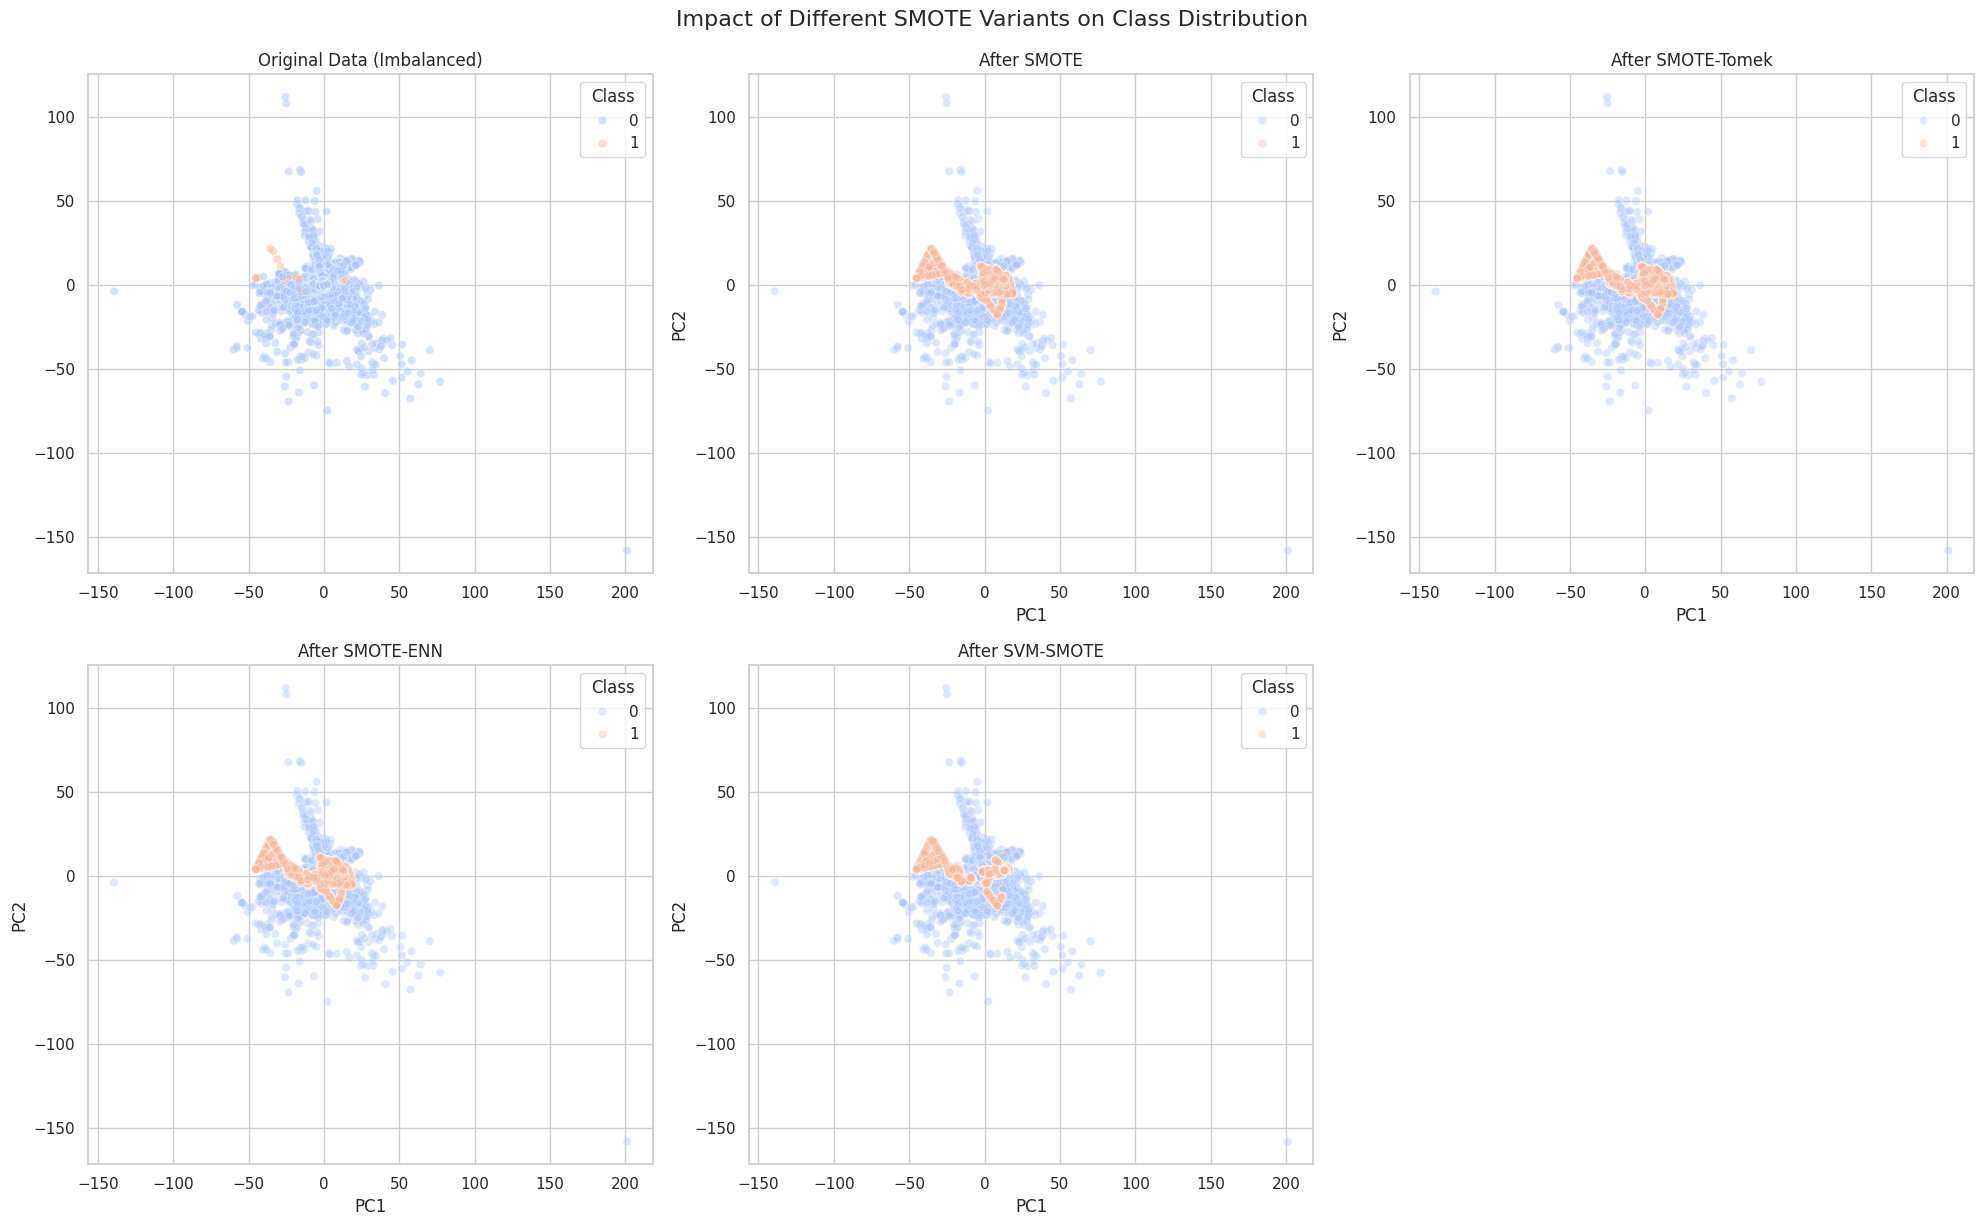

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import pandas as pd

# 1. تحضير الداتا (Preprocessing بسيط باش نقدرو نرسمو)
preprocessor_viz = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(f_classif, k=20)),
    ('pca', PCA(n_components=2)) # كنخدو غير 2 باش نرسمو (X و Y)
])

X_viz = preprocessor_viz.fit_transform(X_train, y_train)

# 2. إعداد المبيانات
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# الحالة الأصلية (Before Resampling)
sns.scatterplot(x=X_viz[:, 0], y=X_viz[:, 1], hue=y_train, ax=axes[0], palette='coolwarm', alpha=0.5)
axes[0].set_title("Original Data (Imbalanced)")

# تطبيق ورسم كل Resampler
for i, (name, resampler) in enumerate(resamplers.items(), 1):
    X_res, y_res = resampler.fit_resample(X_viz, y_train)

    sns.scatterplot(x=X_res[:, 0], y=X_res[:, 1], hue=y_res, ax=axes[i], palette='coolwarm', alpha=0.4)
    axes[i].set_title(f"After {name}")
    axes[i].set_xlabel("PC1")
    axes[i].set_ylabel("PC2")

# حذف المربع الأخير الخاوي
fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle("Impact of Different SMOTE Variants on Class Distribution", fontsize=16, y=1.02)
plt.show()

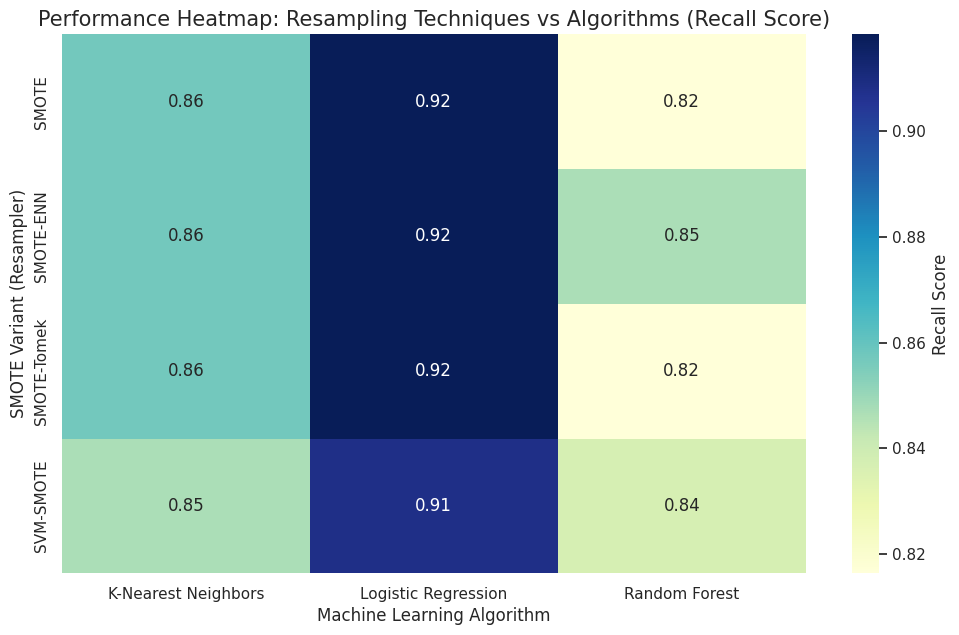

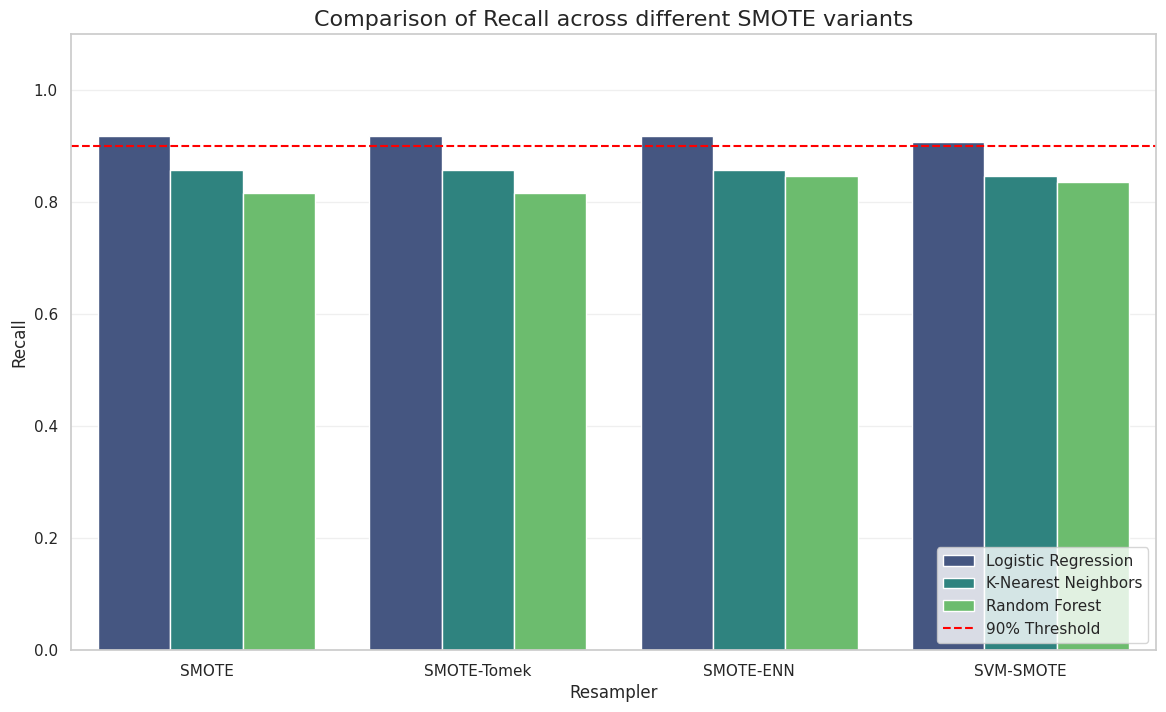

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. تحويل النتائج لجدول Pivot باش نرسمو الـ Heatmap
# غنركزو على الـ Recall حيت هو الأهم فكشف الغش
df_p3_adv = pd.DataFrame(p3_advanced_results)
pivot_recall = df_p3_adv.pivot(index="Resampler", columns="Algorithm", values="Recall")

# 2. رسم الـ Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_recall, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Recall Score'})

plt.title('Performance Heatmap: Resampling Techniques vs Algorithms (Recall Score)', fontsize=15)
plt.xlabel('Machine Learning Algorithm', fontsize=12)
plt.ylabel('SMOTE Variant (Resampler)', fontsize=12)
plt.show()

# 3. مبيان أعمدة مقارن (Clustered Bar Chart) للـ F1-Score والـ Recall معاً
plt.figure(figsize=(14, 8))
sns.barplot(data=df_p3_adv, x='Resampler', y='Recall', hue='Algorithm', palette='viridis')

plt.title('Comparison of Recall across different SMOTE variants', fontsize=16)
plt.axhline(0.90, color='red', linestyle='--', label='90% Threshold') # خط مرجعي
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()

<Figure size 600x500 with 0 Axes>

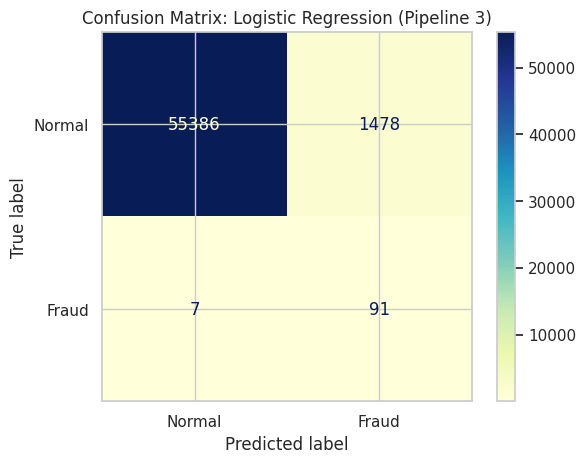

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# بناء الموديل بأفضل إعدادات Pipeline 3 (مثال: Logistic Regression)
best_model_p3 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest(f_classif, k=20)),
    ('pca', PCA(n_components=15)),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

best_model_p3.fit(X_train, y_train)
y_pred_p3 = best_model_p3.predict(X_test)

# رسم المصفوفة
cm = confusion_matrix(y_test, y_pred_p3)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud']).plot(cmap='YlGnBu')
plt.title('Confusion Matrix: Logistic Regression (Pipeline 3)')
plt.show()

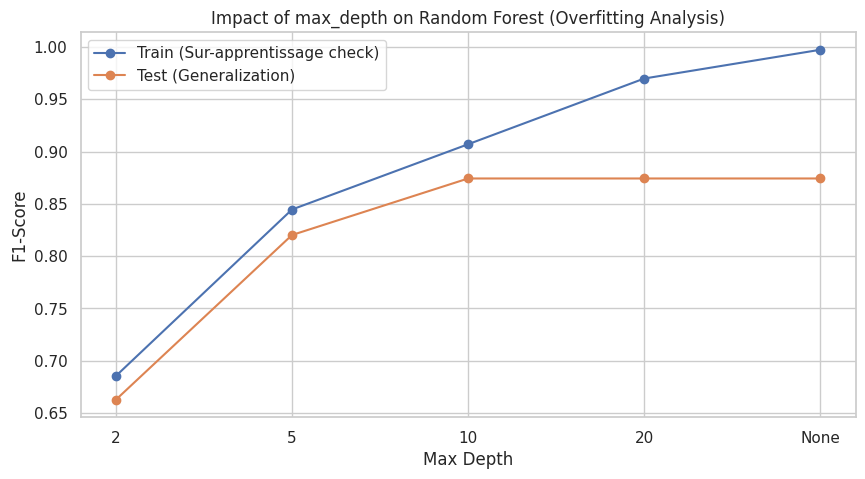

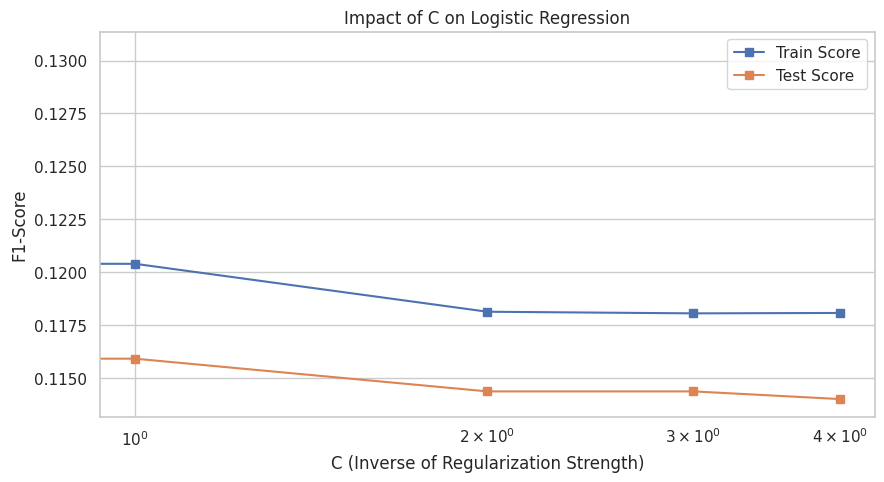

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 4.4 Étude des hyperparamètres
# ==========================================

# --- الموديل 1: Random Forest (تأثير max_depth) ---
depths = [2, 5, 10, 20, None] # None يعني شجرة غاتكبر تا تعيا
train_scores = []
test_scores = []

for d in depths:
    rf = Pipeline([
        ('preprocessor', preprocessor_p2), # كنستعملو Preprocessing ديال P2 أو P3
        ('classifier', RandomForestClassifier(max_depth=d, n_estimators=50, random_state=42))
    ])
    rf.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, rf.predict(X_train)))
    test_scores.append(f1_score(y_test, rf.predict(X_test)))

# رسم مبيان Random Forest
plt.figure(figsize=(10, 5))
plt.plot([str(d) for d in depths], train_scores, label='Train (Sur-apprentissage check)', marker='o')
plt.plot([str(d) for d in depths], test_scores, label='Test (Generalization)', marker='o')
plt.title('Impact of max_depth on Random Forest (Overfitting Analysis)')
plt.xlabel('Max Depth')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.show()

# --- الموديل 2: Logistic Regression (تأثير C) ---
c_values = [0.001, 0.01, 0.1, 1, 10]
lr_train_scores = []
lr_test_scores = []

for c in c_values:
    lr = Pipeline([
        ('preprocessor', preprocessor_p2),
        ('classifier', LogisticRegression(C=c, max_iter=1000, class_weight='balanced', random_state=42))
    ])
    lr.fit(X_train, y_train)
    lr_train_scores.append(f1_score(y_train, lr.predict(X_train)))
    lr_test_scores.append(f1_score(y_test, lr.predict(X_test)))

# رسم مبيان Logistic Regression
plt.figure(figsize=(10, 5))
plt.plot([str(c) for c in c_values], lr_train_scores, label='Train Score', marker='s')
plt.plot([str(c) for c in c_values], lr_test_scores, label='Test Score', marker='s')
plt.xscale('log') # حيت القيم غادة وكتكبر بـ 10x
plt.title('Impact of C on Logistic Regression')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(True)
plt.show()

--- 1. L’importance globale (Global Feature Importance) ---


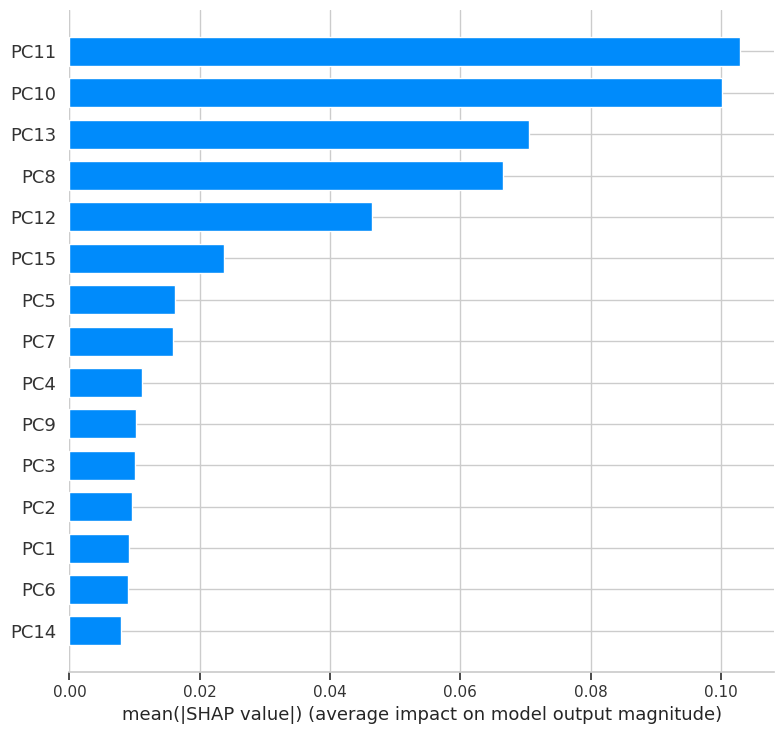

--- 2. Explication locale de la transaction n°840 ---


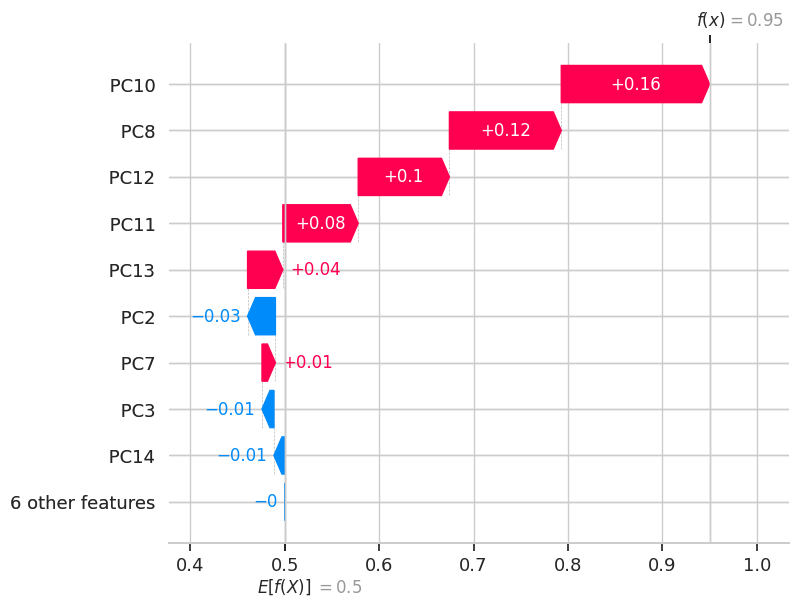

--- 3. Impact des variables (Beeswarm Plot) ---


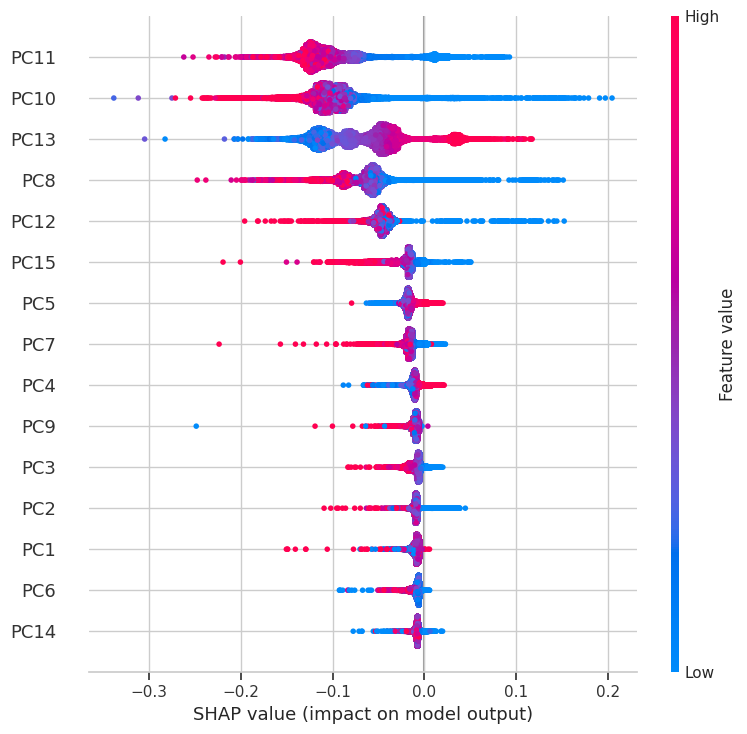

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

# 1. إعداد الموديل النهائي والداتا المحولة
# نستخدم أفضل Pipeline (رقم 3) الذي يحتوي على PCA و RobustScaler
# Correctly define best_pipe as the RandomForestClassifier pipeline from P3
p3_preprocessor_steps = [
    ('imputer', SimpleImputer(strategy='median')), # Median أحسن للـ Outliers
    ('scaler', RobustScaler()),                   # التعامل مع القيم المتطرفة
    ('selector', SelectKBest(f_classif, k=20)),   # اختيار أحسن 20 ميزة
    ('pca', PCA(n_components=15)),                # تقليل الأبعاد لـ 15
]

best_pipe = Pipeline(p3_preprocessor_steps + [
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])
best_pipe.fit(X_train, y_train) # Fit the pipeline

preprocessor = Pipeline(p3_preprocessor_steps) # Create a preprocessor pipeline for transforming X_test
X_test_transformed = preprocessor.transform(X_test)
feature_names = [f"PC{i+1}" for i in range(X_test_transformed.shape[1])]

# 2. إنشاء الـ Explainer وحساب قيم SHAP
# نستخدم TreeExplainer لأنه الأنسب لـ Random Forest
explainer = shap.TreeExplainer(best_pipe.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_transformed)

# معالجة مخرجات SHAP لضمان اختيار فئة "النصب" (Class 1)
# shap_values from TreeExplainer for binary classification can be a list of two arrays (class 0 and class 1)
# or a single 3D array (num_samples, num_features, 2) where the last dimension is for classes.
if isinstance(shap_values, list):
    actual_shap_values = shap_values[1] # For binary classifier, shap_values[1] is for class 1
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3 and shap_values.shape[2] == 2:
    actual_shap_values = shap_values[:, :, 1] # Select SHAP values for class 1 from the 3rd dimension
else:
    actual_shap_values = shap_values

# ---------------------------------------------------------
# • النقطة 1: L’importance globale des variables
# ---------------------------------------------------------
print("--- 1. L’importance globale (Global Feature Importance) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(actual_shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")
# هذا المبيان يحدد أي الـ PCs هي الأكثر حساسية لكشف الغش بشكل عام.

# ---------------------------------------------------------
# • النقطة 2: L’explication locale d'une prédiction
# ---------------------------------------------------------
# سنقوم بشرح المعاملة رقم 840 (كمثال لحالة غش)
idx = 840
print(f"--- 2. Explication locale de la transaction n°{idx} ---")

plt.figure(figsize=(12, 8))
# Ensure the inputs to waterfall_legacy are flat 1D arrays of the correct size
shap.plots._waterfall.waterfall_legacy(
    expected_value=explainer.expected_value[1],
    shap_values=actual_shap_values[idx],
    features=X_test_transformed[idx],
    feature_names=feature_names,
    max_display=10
)
# هذا المبيان يفكك القرار: العوامل الحمراء ترفع احتمال الغش، والزرقاء تخفضه.

# ---------------------------------------------------------
# • النقطة 3: Impact des hyperparamètres sur SHAP values
# ---------------------------------------------------------
# تحليل بصري لكيفية تأثير القيم الأصلية على قيم SHAP
print("--- 3. Impact des variables (Beeswarm Plot) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(actual_shap_values, X_test_transformed, feature_names=feature_names)